```{index} single: logistics
```
```{index} single: solver; HiGHS
```
```{index} network optimization
```
```{index} min-cost flow problem
```
```{index} networkx
```

# 4.2 Minimum-Cost Flow Problem

## Preamble: Install Pyomo and a solver

The following cell sets and verifies a global SOLVER for the notebook. If run on Google Colab, the cell installs Pyomo and the HiGHS solver, while, if run elsewhere, it assumes Pyomo and HiGHS have been previously installed. It then sets to use HiGHS as solver via the appsi module and a test is performed to verify that it is available. The solver interface is stored in a global object `SOLVER` for later use.

In [1]:
import sys
 
if 'google.colab' in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null
 
solver = 'appsi_highs'
 
import pyomo.environ as pyo
SOLVER = pyo.SolverFactory(solver)

assert SOLVER.available(), f"Solver {solver} is not available."

## Problem description

In the context of logistics optimization, a company aims to identify the most cost-effective strategy for transporting goods from its production facilities to its retail locations across an entire continent. 

This problem can be naturally formulated using a graph. Each node $j \in V$ of this network represents a manufacturing facility, a distribution center, or a retail outlet. Correspondingly, node $j$ is characterized by having a supply $b_j>0$, a demand $b_j<0$, or just serving as a transshipment point with $b_j=0$. Each directed arc $(i,j) \in E$ represents a possible mode of transport (rail, airway, road) between locations $i$ and $j$, with an associated maximum capacity $u_{ij} \geq 0$ and cost $c_{ij} \geq 0$ per unit of good sent using edge $(i,j)$. Note that multiple edges are possible between the same pair of nodes $(i,j)$, modeling different means of transport available between those locations, each with a specific cost and maximum capacity. The goal is to identify the cheapest way of transporting goods from the supply nodes to the demand nodes, while respecting the capacity constraints of the arcs and the supply/demand constraints of the nodes.

To distinguish parallel arcs, give each arc a key $k$ in addition to its endpoints: $e=(i,j,k)$. The example below has two separate arcs from node 3 to node 4. Their capacities and costs remain separate throughout the model and the diagrams.


## Mathematical formulation

For each arc $e=(i,j,k)\in E$, let $x_e$ denote its non-negative flow, $c_e$ its unit cost and $u_e$ its capacity. Write $\delta^+(j)$ for the arcs leaving node $j$ and $\delta^-(j)$ for the arcs entering it. The **minimum-cost flow** problem is

$$
\begin{align*}
\min \quad & \sum_{e\in E} c_e x_e \\
\text{s.t.}\quad & \sum_{e\in\delta^+(j)}x_e-\sum_{e\in\delta^-(j)}x_e=b_j && \forall j\in V \\
& 0\leq x_e\leq u_e && \forall e\in E.
\end{align*}
$$

The balance constraint says that outgoing flow minus incoming flow equals the node's supply $b_j$. A negative $b_j$ represents demand. Each parallel arc contributes its own flow to these sums.

The following dictionaries specify a small example. Most endpoint pairs have only key `0`; the pair `(3, 4)` has keys `0` and `1`. Using only `(3, 4)` as a dictionary key twice would overwrite the first arc.


In [2]:
network = {
    "nodes": {
        0: {"b": 15},
        1: {"b": 0},
        2: {"b": 0},
        3: {"b": 0},
        4: {"b": -1},
        5: {"b": -1},
        6: {"b": -2},
        7: {"b": -2},
        8: {"b": -2},
        9: {"b": -2},
        10: {"b": -5},
    },
    "edges": {
        (0, 1, 0): {"u": 15, "c": 1},
        (1, 2, 0): {"u": 15, "c": 1},
        (2, 9, 0): {"u": 10, "c": 1},
        (2, 3, 0): {"u": 15, "c": 1},
        (3, 4, 0): {"u": 15, "c": 1},
        (3, 5, 0): {"u": 10, "c": 2},
        (3, 4, 1): {"u": 10, "c": 3},
        (4, 7, 0): {"u": 4, "c": 1},
        (4, 8, 0): {"u": 5, "c": 4},
        (5, 8, 0): {"u": 5, "c": 3},
        (5, 9, 0): {"u": 6, "c": 2},
        (5, 10, 0): {"u": 5, "c": 1},
        (8, 6, 0): {"u": 8, "c": 3},
        (6, 10, 0): {"u": 1, "c": 3},
        (7, 8, 0): {"u": 4, "c": 2},
        (7, 10, 0): {"u": 2, "c": 2},
        (8, 10, 0): {"u": 5, "c": 3},
        (9, 10, 0): {"u": 3, "c": 1},
    },
}

We first introduce an auxiliary function to draw the network and its features.

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import Markdown, display


def draw_network(network, ax=None, edge_flows=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 11))
    g = nx.MultiDiGraph()
    g.add_nodes_from(network["nodes"])
    for (i, j, k), data in network["edges"].items():
        g.add_edge(i, j, key=k, **data)
    pos = nx.kamada_kawai_layout(g, weight=None)
    styles = ["arc3,rad=0.08", "arc3,rad=-0.22"]
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color="tab:blue")
    nx.draw_networkx_labels(g, pos, ax=ax, font_color="white")
    edges = list(g.edges(keys=True))
    nx.draw_networkx_edges(
        g, pos, ax=ax, edgelist=edges, connectionstyle=styles,
        width=[2.5 if edge_flows is not None and edge_flows[e] > 0 else 1 for e in edges],
        edge_color=["tab:blue" if edge_flows is not None and edge_flows[e] > 0 else "gray" for e in edges],
    )
    labels = {
        e: f"k={e[2]}, u={data['u']}, c={data['c']}" if edge_flows is None
        else f"k={e[2]}, x={edge_flows[e]:g}"
        for e, data in network["edges"].items()
    }
    nx.draw_networkx_edge_labels(g, pos, ax=ax, edge_labels=labels,
                                 connectionstyle=styles, font_size=8)
    # Put supply/demand labels just above nodes with a clear background.
    for j, data in network["nodes"].items():
        b = data["b"]
        ax.annotate(
            f"b={b}", xy=pos[j], xytext=(0, 14),
            textcoords="offset points", ha="center",
            va="bottom", fontsize=10,
            color="red" if b < 0 else "green" if b > 0 else "gray",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 1},
        )
    ax.margins(0.12)
    ax.set_axis_off()


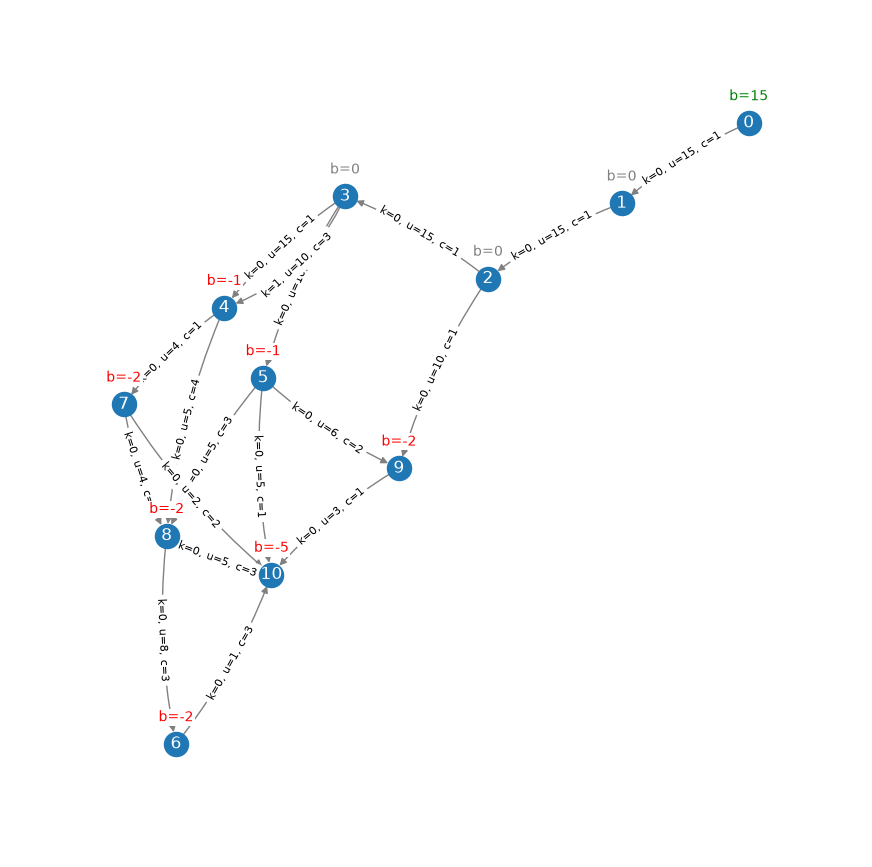

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(11, 11))
draw_network(network, ax=ax)

In the next cell, we formulate the MCF problem using Pyomo, solve it, and visualize the solution.


Optimal solution:


$x_{0,1,0}=15$, $x_{1,2,0}=15$, $x_{2,9,0}=5$, $x_{2,3,0}=10$, $x_{3,4,0}=5$, $x_{3,5,0}=5$, $x_{3,4,1}=0$, $x_{4,7,0}=4$, $x_{4,8,0}=0$, $x_{5,8,0}=2$, $x_{5,9,0}=0$, $x_{5,10,0}=2$, $x_{8,6,0}=2$, $x_{6,10,0}=0$, $x_{7,8,0}=2$, $x_{7,10,0}=0$, $x_{8,10,0}=0$, $x_{9,10,0}=3$

Objective value: 85


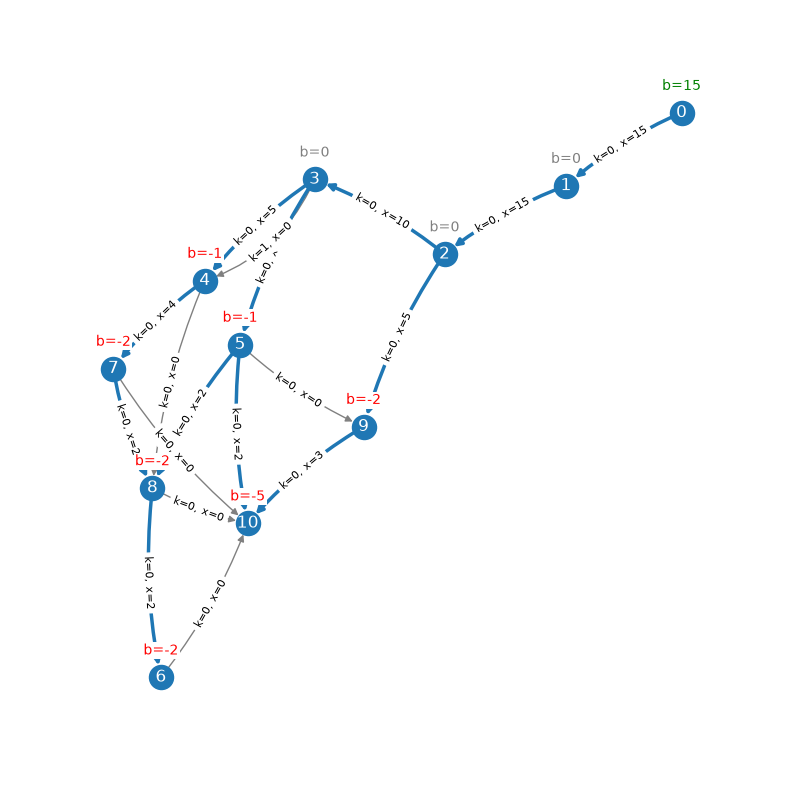

In [5]:
def mincostflow(network):
    model = pyo.ConcreteModel("Minimum cost flow")

    model.x = pyo.Var(network["edges"], domain=pyo.NonNegativeReals)

    @model.Objective(sense=pyo.minimize)
    def objective(m):
        return sum(data["c"] * m.x[e] for e, data in network["edges"].items())

    @model.Expression(network["nodes"])
    def incoming_flow(m, j):
        return sum(m.x[e] for e in network["edges"] if e[1] == j)

    @model.Expression(network["nodes"])
    def outgoing_flow(m, j):
        return sum(m.x[e] for e in network["edges"] if e[0] == j)

    @model.Constraint(network["nodes"])
    def flow_conservation(m, j):
        return m.outgoing_flow[j] - m.incoming_flow[j] == network["nodes"][j]["b"]

    @model.Constraint(network["edges"])
    def flow_upper_bound(m, *e):
        return m.x[e] <= network["edges"][e]["u"]

    return model


model = mincostflow(network)
results = SOLVER.solve(model)
pyo.assert_optimal_termination(results)
flows = {e: model.x[e].value for e in network["edges"]}
print("\nOptimal solution:")
display(
    Markdown(
        ", ".join(f"$x_{{{i},{j},{k}}}={model.x[i,j,k]():g}$" for i,j,k in network["edges"])
    )
)
print(f"Objective value: {model.objective():.0f}")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
draw_network(network, ax=ax, edge_flows=flows)